# 1 - Data Preparation

In [ ]:
# ==============================================================================
# CÉLULA MESTRE DE PREPARAÇÃO DE DADOS (VERSÃO FINAL E COMPLETA)
# ==============================================================================
import numpy as np
import pandas as pd
from pathlib import Path
from typing import Dict, List, Tuple

try:
    import irsdk
    IRSDK_AVAILABLE = True
except Exception:
    IRSDK_AVAILABLE = False

# --- 2. CONFIGURAÇÃO GERAL ---
USE_IBT = True
ibt_file = Path("data/mx5 mx52016_charlotte 2018 2019 roval 2025-08-02 12-13-03.ibt")
TARGET_LAP_TO_ANALYZE = 6
N_SECTORS = 4
BASE_GRID_LEN = 1000
TOPK_PERCENT = 0.30
PACE_THRESHOLD_MS = 3000.0
SEQ_LEN = 128
OUT_DIR = Path("iracing_outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# --- 3. DEFINIÇÃO DAS FUNÇÕES AUXILIARES ---

def load_from_ibt(ibt_path: Path) -> pd.DataFrame:
    if not IRSDK_AVAILABLE: raise RuntimeError("irsdk is not available.")
    if not ibt_path.exists(): raise FileNotFoundError(f".ibt file not found: {ibt_path}")
    
    ibt = irsdk.IBT()
    try:
        ibt.open(str(ibt_path))
        # <<< PONTO CRÍTICO 1: GARANTIR QUE OS CANAIS ESTÃO NA LISTA >>>
        channels = [
            'SessionTime','Lap','LapDistPct',
            'Speed','RPM','Throttle','Brake',
            'LatAccel','SteeringWheelAngle','Gear' # Essenciais para as heurísticas avançadas
        ]
        data = {ch: ibt.get_all(ch) for ch in channels}
    finally:
        ibt.close()
    return pd.DataFrame(data)

def basic_clean_and_units(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.dropna(inplace=True)
    df["Speed_KPH"] = df["Speed"] * 3.6
    df["Throttle_Pct"] = df["Throttle"] * 100.0
    df["Brake_Pct"] = df["Brake"] * 100.0
    return df

def lap_time_seconds(g: pd.DataFrame) -> float:
    gs = g.sort_values("SessionTime")
    return float(gs["SessionTime"].iloc[-1] - gs["SessionTime"].iloc[0])

def build_lap_validity_table(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for lap, g in df.groupby("Lap"):
        if len(g) < 10: continue
        rows.append({
            "Lap": int(lap), "LapTime_s": lap_time_seconds(g),
            "CompletedPct": float(g["LapDistPct"].max()),
            "FracLowSpeed": float((g["Speed_KPH"] < 10.0).mean()),
            "MaxSpeed_kph": float(g["Speed_KPH"].max()),
        })
    lap_df = pd.DataFrame(rows).sort_values("Lap").reset_index(drop=True)
    valid = ( (lap_df["CompletedPct"] >= 0.98) & (lap_df["FracLowSpeed"] <= 0.25) & (lap_df["MaxSpeed_kph"] >= 60.0) )
    lap_df["Valid"] = valid
    if lap_df["Valid"].sum() >= 5:
        q1, q3 = lap_df.loc[lap_df["Valid"], "LapTime_s"].quantile([0.25, 0.75])
        iqr = float(q3 - q1); hi = float(q3 + 1.5 * iqr); lo = max(0.0, float(q1 - 1.5 * iqr))
        lap_df.loc[:, "Valid"] &= lap_df["LapTime_s"].between(lo, hi)
    return lap_df

def align_lap_by_dist(g: pd.DataFrame, grid: np.ndarray) -> Dict[str, np.ndarray]:
    g = g.sort_values("LapDistPct").drop_duplicates(subset=["LapDistPct"], keep="first")
    if len(g) < 2: return {}
    t_rel = g["SessionTime"] - g["SessionTime"].iloc[0]
    x = g["LapDistPct"].to_numpy()
    def interp(y: np.ndarray) -> np.ndarray: return np.interp(grid, x, y)
    out = {
        "t_rel": interp(t_rel.to_numpy()), "speed": interp(g["Speed_KPH"].to_numpy()),
        "throttle": interp(g["Throttle_Pct"].to_numpy()), "brake": interp(g["Brake_Pct"].to_numpy()),
    }
    # <<< PONTO CRÍTICO 2: GARANTIR QUE OS CANAIS SÃO INTERPOLADOS >>>
    for col in ["RPM", "LatAccel", "SteeringWheelAngle", "Gear"]:
        if col in g.columns: out[col] = interp(g[col].to_numpy())
    return out

def sector_edges(n_points: int, n_sectors: int) -> List[Tuple[int,int]]:
    edges = np.linspace(0, n_points-1, n_sectors+1).astype(int)
    return [(edges[i], edges[i+1]) for i in range(n_sectors)]

def resample_idx(n_src: int, n_dst: int) -> np.ndarray:
    return np.linspace(0, n_src-1, n_dst).astype(int)

def sector_features(sec: pd.DataFrame) -> Dict[str, float]:
    arr = {k: sec[k].to_numpy() for k in sec.columns}
    d = {}
    
    d["time_s"] = float(arr["t_rel"][-1] - arr["t_rel"][0])
    d["spe_mean"]= float(arr["speed"].mean()); d["spe_max"]= float(arr["speed"].max()); d["spe_min"]= float(arr["speed"].min())
    d["thr_on_ratio"] = float((arr["throttle"] > 5).mean()); d["bra_on_ratio"] = float((arr["brake"] > 5).mean())
    d["coa_ratio"] = float(((arr["throttle"] < 5) & (arr["brake"] < 5)).mean())
    
    if "SteeringWheelAngle" in arr:
        d["steer_std_dev"] = float(arr["SteeringWheelAngle"].std())
        
        # O limiar foi ajustado de 15 (um valor impossível em radianos) para 0.2 (~11.5 graus).
        turning_mask = np.abs(arr["SteeringWheelAngle"]) > 0.2 
        
        if "LatAccel" in arr and np.any(turning_mask):
            
            d["grip_ratio"] = np.mean(np.abs(arr["LatAccel"][turning_mask]) / np.abs(arr["SteeringWheelAngle"][turning_mask]))

    if len(arr["throttle"]) > 1:
        d["thr_attack_rate"] = float(np.max(np.diff(arr["throttle"], prepend=arr["throttle"][0])))
    
    if "Gear" in arr and len(arr["Gear"]) > 0:
        d["gear_at_apex"] = int(arr["Gear"][arr["speed"].argmin()])
        
    return d

def build_sector_table_no_ref(df: pd.DataFrame, valid_laps: List[int], n_sectors: int, seq_len: int) -> pd.DataFrame:
    grid = np.linspace(0.0, 1.0, BASE_GRID_LEN)
    rows = []
    for lap in valid_laps:
        interp = align_lap_by_dist(df[df["Lap"]==lap], grid)
        if not interp: continue
        raw = pd.DataFrame(interp)
        edges = sector_edges(len(raw), n_sectors)
        for sid,(a,b) in enumerate(edges, start=1):
            sec = raw.iloc[a:b+1].copy()
            idx = resample_idx(len(sec), seq_len)
            feats = sector_features(sec.iloc[idx].reset_index(drop=True))
            feats.update({"lap": int(lap), "sector": int(sid)})
            rows.append(feats)
    return pd.DataFrame(rows)

def build_ref_sector_times_topk(df, valid_laps, n_sectors, base_grid_len=1000, k_percent=0.3):
    grid = np.linspace(0.0, 1.0, base_grid_len)
    lap_times = pd.DataFrame({"lap": valid_laps, "lap_time": [lap_time_seconds(df[df["Lap"]==l]) for l in valid_laps]}).sort_values("lap_time")
    k = max(1, int(len(lap_times) * k_percent))
    top_laps = lap_times.head(k)["lap"].tolist()
    per = []
    for lap in top_laps:
        interp = align_lap_by_dist(df[df["Lap"]==lap], grid)
        if not interp: continue
        edges = sector_edges(len(interp["t_rel"]), n_sectors)
        for sid,(a,b) in enumerate(edges, start=1):
            per.append({"sector": sid, "time_s": float(interp["t_rel"][b]-interp["t_rel"][a])})
    return pd.DataFrame(per).groupby("sector")["time_s"].median().to_dict()

# --- 4. BLOCO DE EXECUÇÃO PRINCIPAL ---
print("Iniciando pipeline de preparação de dados...")
if USE_IBT:
    print(f"Carregando dados do arquivo IBT: {ibt_file}")
    df = load_from_ibt(ibt_file)
else:
    if 'df' not in locals(): raise NameError("DataFrame 'df' não encontrado. Rode com USE_IBT=True primeiro.")
    print("Usando DataFrame 'df' já existente na memória.")
df = basic_clean_and_units(df)
print(f"Dados brutos carregados e limpos. Total de {len(df)} linhas.")
print("\nConstruindo tabela de validade das voltas...")
lap_df = build_lap_validity_table(df)
valid_laps = lap_df[lap_df["Valid"]]["Lap"].tolist()
print(f"Análise de validade concluída. Voltas válidas encontradas: {valid_laps}")
print("\nConstruindo tabela de features por setor (pode demorar)...")
feat_table = build_sector_table_no_ref(df, valid_laps, N_SECTORS, SEQ_LEN)
print("Tabela de features inicial construída.")
print("Calculando tempos de referência e aplicando filtro de ritmo...")
ref_map = build_ref_sector_times_topk(df, valid_laps, N_SECTORS, k_percent=TOPK_PERCENT)
feat_table["ref_time_sec"] = feat_table["sector"].map(ref_map)
feat_table["delta_ms"] = 1000.0 * (feat_table["time_s"] - feat_table["ref_time_sec"])
ref_lap_row = lap_df[lap_df['Valid']].sort_values('LapTime_s').iloc[0]
ref_lap = int(ref_lap_row['Lap'])
target_lap = TARGET_LAP_TO_ANALYZE
sum_pos = feat_table.groupby("lap")["delta_ms"].sum().clip(lower=0).reset_index(name="loss_ms")
laps_within_pace = sum_pos[sum_pos["loss_ms"] < PACE_THRESHOLD_MS]["lap"].tolist()
keep_laps_set = set(laps_within_pace)
keep_laps_set.add(ref_lap)
keep_laps_set.add(target_lap)
keep_laps = sorted(list(keep_laps_set))
feat_table = feat_table[feat_table["lap"].isin(keep_laps)].reset_index(drop=True)
print(f"Filtro de ritmo aplicado. Voltas mantidas na feat_table: {keep_laps}")
print(f"\nPipeline de preparação de dados concluído com sucesso!")
print("Os DataFrames 'lap_df' e 'feat_table' estão prontos na memória.")
print("\nAmostra da tabela de features final (feat_table):")
display(feat_table.head())

Iniciando pipeline de preparação de dados...
Carregando dados do arquivo IBT: data\mx5 mx52016_charlotte 2018 2019 roval 2025-08-02 12-13-03.ibt
Dados brutos carregados e limpos. Total de 84816 linhas.

Construindo tabela de validade das voltas...
Análise de validade concluída. Voltas válidas encontradas: [2, 4, 5, 6, 8, 9, 10]

Construindo tabela de features por setor (pode demorar)...
Tabela de features inicial construída.
Calculando tempos de referência e aplicando filtro de ritmo...
Filtro de ritmo aplicado. Voltas mantidas na feat_table: [2, 4, 5, 6, 8, 9, 10]

Pipeline de preparação de dados concluído com sucesso!
Os DataFrames 'lap_df' e 'feat_table' estão prontos na memória.

Amostra da tabela de features final (feat_table):


,time_s,spe_mean,spe_max,spe_min,thr_on_ratio,bra_on_ratio,coa_ratio,steer_std_dev,grip_ratio,thr_attack_rate,gear_at_apex,lap,sector,ref_time_sec,delta_ms
0,26.686016,121.698547,140.175945,89.903011,0.812500,0.140625,0.078125,0.493119,19.834050,66.119548,2,2,1,25.214200,1471.816678
1,25.929894,126.614311,152.500962,93.707158,0.773438,0.109375,0.117188,0.424625,22.115848,56.242584,2,2,2,26.158666,-228.771327
2,22.755562,150.945562,187.455315,84.329976,0.835938,0.125000,0.039062,0.256926,23.149464,47.303752,2,2,3,22.695164,60.397837
3,21.195194,155.647361,182.423261,115.146601,0.851562,0.093750,0.062500,0.160854,26.965337,39.999998,3,2,4,21.831971,-636.776521
4,26.361385,123.230512,144.892099,96.439989,0.796875,0.109375,0.101562,0.449923,22.345203,53.682276,2,4,1,25.214200,1147.184965


# 1 - Train Model

In [20]:
# ==============================================================================
# CÉLULA DE TREINAMENTO DO MODELO
# ==============================================================================
# Prepara os dados, divide em treino/teste e treina o modelo de regressão.
# ==============================================================================
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_absolute_error
from sklearn.ensemble import RandomForestRegressor

# --- 1. Preparação para Modelagem ---

CLIP_MS = 1500.0  # Limita a perda/ganho máximo para o treinamento do modelo
SEED = 42         # Semente para reprodutibilidade

# Define as colunas que serão usadas como features (X) e a coluna alvo (y)
CANDIDATE_COLS = [
    'spe_mean', 'spe_max', 'spe_min',
    'thr_on_ratio', 'coa_ratio', 'bra_on_ratio',
    'steer_std_dev', 'grip_ratio', 'thr_attack_rate', 'gear_at_apex'
]
TARGET_COL = "delta_ms"

# Garante que estamos usando apenas as colunas que realmente existem na feat_table
features = [col for col in CANDIDATE_COLS if col in feat_table.columns]
print(f"Features que serão usadas no modelo: {features}")

model_df = feat_table.dropna(subset=features + [TARGET_COL]).copy()

X = model_df[features]
y = model_df[TARGET_COL].clip(-CLIP_MS, CLIP_MS)
laps = model_df["lap"]


# --- 2. Divisão de Dados (Treino e Teste) ---
kf = GroupKFold(n_splits=5)
train_idx, test_idx = next(kf.split(X, y, groups=laps))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

print(f"\nDados divididos em {len(X_train)} amostras de treino e {len(X_test)} de teste.")


# --- 3. Treinamento do Modelo (Random Forest) ---
model = RandomForestRegressor(n_estimators=100, min_samples_leaf=5, n_jobs=-1, random_state=SEED)
model.fit(X_train, y_train)

predictions = model.predict(X_test)
mae = mean_absolute_error(y_test, predictions)
print(f"\nModelo treinado com sucesso.")
print(f"Erro Médio Absoluto (MAE) no conjunto de teste: {mae:.1f} ms")
print("\nA variável 'model' está pronta para ser usada na próxima célula.")

Features que serão usadas no modelo: ['spe_mean', 'spe_max', 'spe_min', 'thr_on_ratio', 'coa_ratio', 'bra_on_ratio', 'steer_std_dev', 'grip_ratio', 'thr_attack_rate', 'gear_at_apex']

Dados divididos em 20 amostras de treino e 8 de teste.

Modelo treinado com sucesso.
Erro Médio Absoluto (MAE) no conjunto de teste: 198.6 ms

A variável 'model' está pronta para ser usada na próxima célula.


# 2 - Feature Importance


Calculando importância por permutação (pode demorar um pouco)...
Cálculo concluído.

--- Importância das Features (Nativa do Modelo) ---


,feature,importance
0,spe_max,0.355002
1,spe_mean,0.214242
2,grip_ratio,0.140724
3,thr_on_ratio,0.083261
4,thr_attack_rate,0.060000
5,bra_on_ratio,0.060000
6,spe_min,0.050860
7,steer_std_dev,0.030000
8,coa_ratio,0.005911
9,gear_at_apex,0.000000



--- Importância das Features (por Permutação) ---


,feature,importance_mean,importance_std
0,spe_max,2.845831e-01,1.478044e-01
1,spe_mean,1.541651e-01,8.549347e-02
2,thr_on_ratio,5.566765e-02,3.187825e-02
3,grip_ratio,4.949608e-02,4.982335e-02
4,thr_attack_rate,2.990127e-02,1.747124e-02
5,coa_ratio,4.991109e-03,2.771918e-03
6,steer_std_dev,3.134955e-03,1.125636e-02
7,gear_at_apex,1.443290e-16,1.574013e-16
8,bra_on_ratio,-6.445994e-04,2.426332e-02
9,spe_min,-5.379136e-03,1.539405e-02


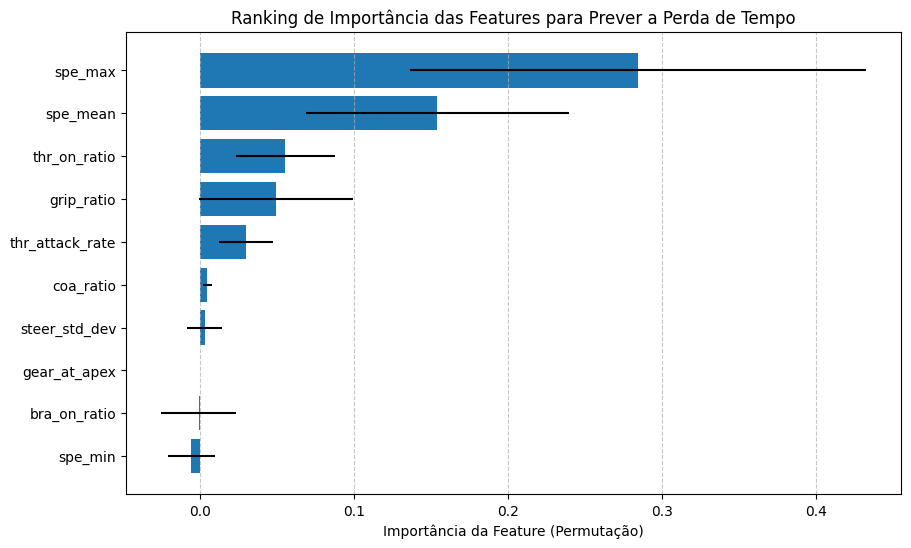

In [21]:
# ==============================================================================
# CÉLULA DE ANÁLISE DE FEATURE IMPORTANCE
# ==============================================================================
# Usa o modelo treinado na célula anterior para descobrir quais features
# são mais importantes para prever a perda de tempo.
# ==============================================================================
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

# --- 1. Análise de Feature Importance ---

# Método 1: Importância nativa do modelo (rápido)
model_importance = pd.DataFrame({
    'feature': features,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True)

# Método 2: Importância por Permutação (mais robusto)
print("\nCalculando importância por permutação (pode demorar um pouco)...")
perm_importance_result = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=SEED, n_jobs=-1)
perm_importance = pd.DataFrame({
    'feature': features,
    'importance_mean': perm_importance_result.importances_mean,
    'importance_std': perm_importance_result.importances_std,
}).sort_values('importance_mean', ascending=False).reset_index(drop=True)
print("Cálculo concluído.")

print("\n--- Importância das Features (Nativa do Modelo) ---")
display(model_importance)

print("\n--- Importância das Features (por Permutação) ---")
display(perm_importance)


# --- 2. Visualização da Feature Importance ---

plt.figure(figsize=(10, 6))
plt.barh(perm_importance['feature'], perm_importance['importance_mean'], xerr=perm_importance['importance_std'], align='center')
plt.gca().invert_yaxis()
plt.xlabel("Importância da Feature (Permutação)")
plt.title("Ranking de Importância das Features para Prever a Perda de Tempo")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()